<H1 style="text-align: center">COM3023 Machine Learning and AI </H1>
<H1 style="text-align: center">Workshop: Reinforcement Learning</H1>

# Q-Learning


In [ ]:
import numpy as np

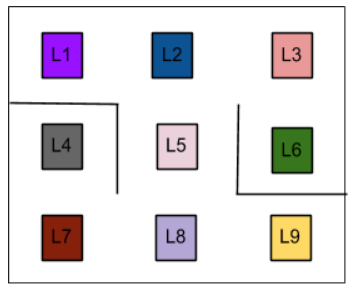

In [ ]:
# Initialize parameters
gamma = 0.8 # discounting factor
alpha = 0.9 # learning rate

In [ ]:
# Define the states
location_to_state = {
    'L1' : 0,
    'L2' : 1,
    'L3' : 2,
    'L4' : 3,
    'L5' : 4,
    'L6' : 5,
    'L7' : 6,
    'L8' : 7,
    'L9' : 8
}

In [ ]:
# Define the actions
actions = [0,1,2,3,4,5,6,7,8]

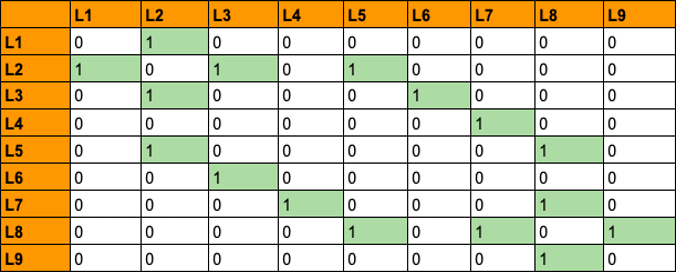

In [ ]:
# Define the rewards
rewards = np.array([[0,1,0,0,0,0,0,0,0],
              [1,0,1,0,0,0,0,0,0],
              [0,1,0,0,0,1,0,0,0],
              [0,0,0,0,0,0,1,0,0],
              [0,1,0,0,0,0,0,1,0],
              [0,0,1,0,0,0,0,0,0],
              [0,0,0,1,0,0,0,1,0],
              [0,0,0,0,1,0,1,0,1],
              [0,0,0,0,0,0,0,1,0]])

In [ ]:
# Maps indices to locations
state_to_location = dict((state,location) for location,state in location_to_state.items())

In [ ]:
def get_optimal_route(start_location,end_location):
    # Copy the rewards matrix to new Matrix
    rewards_new = np.copy(rewards)
    # Get the ending state corresponding to the ending location as given
    ending_state = location_to_state[end_location]
    # With the above information automatically set the priority of the given ending state to the highest one
    rewards_new[ending_state,ending_state] = 999

    # -----------Q-Learning algorithm-----------

    # Initializing Q-Values
    Q = np.array(np.zeros([9,9]))

    # Q-Learning process
    for i in range(1000):
        # Pick up a state randomly
        current_state = np.random.randint(0,9) # Python excludes the upper bound
        # For traversing through the neighbor locations in the maze
        playable_actions = []
        # Iterate through the new rewards matrix and get the actions > 0
        for j in range(9):
            if rewards_new[current_state,j] > 0:
                playable_actions.append(j)
        # Pick an action randomly from the list of playable actions leading us to the next state
        next_state = np.random.choice(playable_actions)
        # Compute the temporal difference
            # The action here exactly refers to going to the next state
        TD = rewards_new[current_state,next_state] + gamma * Q[next_state, np.argmax(Q[next_state,])] - Q[current_state,next_state]
        # Update the Q-Value using the Bellman equation
        Q[current_state,next_state] += alpha * TD

    # Initialize the optimal route with the starting location
    route = [start_location]
    # We do not know about the next location yet, so initialize with the value of starting location
    next_location = start_location

    # We don't know about the exact number of iterations needed to reach to the final location hence while loop will be a good choice for iteratiing
    while(next_location != end_location):
        # Fetch the starting state
        starting_state = location_to_state[start_location]
        # Fetch the highest Q-value pertaining to starting state
        next_state = np.argmax(Q[starting_state,])
        # We got the index of the next state. But we need the corresponding letter.
        next_location = state_to_location[next_state]
        route.append(next_location)
        # Update the starting location for the next iteration
        start_location = next_location

    return route

In [ ]:
print(get_optimal_route('L8', 'L3')) # Try a new starting and ending location


['L8', 'L5', 'L2', 'L3']


# 🎰 Multi-Armed Bandit: Implementing the ε-Greedy Algorithm

## **Problem Statement**
Imagine you are at a casino playing a **slot machine game** with **5 different slot machines** (also called "arms"). Each machine has an **unknown probability of winning** (payout rate), but you don't know which one is the best.

Your task is to implement the **ε-Greedy algorithm** to **maximize your total winnings** over **10,000 plays**.

## **How the Multi-Armed Bandit Works**
- Each slot machine **has a fixed probability of winning** (between 0 and 1).
- Every time you pull a lever (choose an arm), you **either win (reward = 1) or lose (reward = 0)**.
- The goal is to **identify the best machine** while still exploring new options.

## **Algorithm Breakdown**
To balance **exploration and exploitation**, use the **ε-Greedy strategy**:
1. **With probability $1 - \epsilon$**, choose the machine with the highest estimated reward (**exploitation**).
2. **With probability $\epsilon$**, choose a random machine (**exploration**).
3. **Update the estimated reward** for the selected machine using:
   $$
   Q(a) \leftarrow Q(a) + \frac{1}{N} (R - Q(a))
   $$
   where:
   - **$Q(a)$** is the estimated reward for machine $a$
   - **$R$** is the actual reward received (1 for win, 0 for loss)
   - **$N$** is the number of times machine $a$ has been chosen.

## **Your Task**
1. Implement the function `epsilon_greedy_bandit()`.
2. Run the **ε-Greedy algorithm** for **1,000 plays**.
3. Print the estimated best machine and the estimated reward probabilities.


In [ ]:
import numpy as np

def epsilon_greedy_bandit(true_probabilities, epsilon=0.1, trials=1000):
    """
    Implements the ε-Greedy algorithm for a Multi-Armed Bandit problem.

    Args:
    - true_probabilities: (list) The true win probabilities for each machine.
    - epsilon: (float) Probability of exploration.
    - trials: (int) Number of plays.

    Returns:
    - estimated_rewards: (numpy array) Estimated win rates for each machine.
    - best_machine: (int) Index of the best machine.
    """
    num_machines = len(true_probabilities)

    # Initialize estimated rewards and visit counts
    estimated_rewards = np.zeros(num_machines)
    visit_counts = np.zeros(num_machines)

    for t in range(trials):
        if np.random.rand() < epsilon:
            # Exploration - Pick a random machine
            action = np.random.randint(num_machines)
        else:
            # Exploitation - Pick the machine with the highest estimated reward
            action = np.argmax(estimated_rewards)

        # Simulate pulling the slot machine (win = 1 with probability true_probabilities[action])
        reward = 1 if np.random.rand() < true_probabilities[action] else 0

        # Update estimated rewards using incremental mean formula
        visit_counts[action] += 1
        estimated_rewards[action] += (reward - estimated_rewards[action]) / visit_counts[action]

    # Identify the best machine based on estimated rewards
    best_machine = np.argmax(estimated_rewards)

    return estimated_rewards, best_machine


In [ ]:
# slot machines with different true probabilities
true_probabilities = [0.2, 0.5, 0.3, 0.7, 0.4]  # Unknown to the agent

In [ ]:
# Run the bandit algorithm
estimated_rewards, best_machine = epsilon_greedy_bandit(true_probabilities)

print("Estimated Rewards:", estimated_rewards)
print("Best Machine:", best_machine)

#Try different values of epsilon and trials.

Estimated Rewards: [0.2        0.54545455 0.35714286 0.71020856 0.45      ]
Best Machine: 3
